# ISLES 2022 — Exploratory Data Analysis

**Dataset:** ISLES 2022 (Ischemic Stroke Lesion Segmentation Challenge 2022)  
**Source:** [Zenodo](https://zenodo.org/record/7153326)  
**Modalities:** DWI (b=1000), ADC, FLAIR  
**Task:** Acute ischemic stroke lesion segmentation

---

## Goals

1. Understand the dataset structure
2. Characterise the lesion size distribution
3. Check voxel spacing and volume dimensions
4. Visualise representative cases
5. Identify difficult cases (posterior fossa, tiny, multifocal)
6. Decide on a cross-validation split strategy

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib
from tqdm.auto import tqdm

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Project root added to sys.path")

Project root added to sys.path


## 1. Dataset structure

In [2]:
data_root = project_root / "data" / "raw" / "isles22" / "ISLES-2022"
derivatives_root = project_root / "data" / "raw" / "isles22" / "derivatives"

# Find every case
subjects = sorted([d.name for d in data_root.glob("sub-*") if d.is_dir()])
print(f"Total cases: {len(subjects)}")
print(f"Example ID: {subjects[0]}")

Total cases: 250
Example ID: sub-strokecase0001


In [3]:
# Inspect the layout of a single case
example_sub = subjects[0]
example_path = data_root / example_sub / "ses-0001"

print(f"Layout of {example_sub}:")
def _rel(paths):
    """Show paths relative to the project root, not absolute."""
    return [p.relative_to(project_root).as_posix() for p in paths]

print(f"  DWI:   {_rel(example_path.glob('dwi/*dwi.nii.gz'))}")
print(f"  ADC:   {_rel(example_path.glob('dwi/*adc.nii.gz'))}")
print(f"  FLAIR: {_rel(example_path.glob('anat/*FLAIR.nii.gz'))}")
print(f"  Mask:  {_rel((derivatives_root / example_sub / 'ses-0001').glob('*msk.nii.gz'))}")

Layout of sub-strokecase0001:
  DWI:   ['data/raw/isles22/ISLES-2022/sub-strokecase0001/ses-0001/dwi/sub-strokecase0001_ses-0001_dwi.nii.gz']
  ADC:   ['data/raw/isles22/ISLES-2022/sub-strokecase0001/ses-0001/dwi/sub-strokecase0001_ses-0001_adc.nii.gz']
  FLAIR: ['data/raw/isles22/ISLES-2022/sub-strokecase0001/ses-0001/anat/sub-strokecase0001_ses-0001_FLAIR.nii.gz']
  Mask:  ['data/raw/isles22/derivatives/sub-strokecase0001/ses-0001/sub-strokecase0001_ses-0001_msk.nii.gz']


## 2. Data loading helpers

In [4]:
def load_subject_paths(subject_id: str) -> dict:
    """Return the paths to every file belonging to one case."""
    sub_path = data_root / subject_id / "ses-0001"
    deriv_path = derivatives_root / subject_id / "ses-0001"
    
    dwi = list(sub_path.glob("dwi/*dwi.nii.gz"))[0]
    adc = list(sub_path.glob("dwi/*adc.nii.gz"))[0]
    flair = list(sub_path.glob("anat/*FLAIR.nii.gz"))[0]
    mask = list(deriv_path.glob("*msk.nii.gz"))[0]
    
    return {
        "subject_id": subject_id,
        "dwi": dwi,
        "adc": adc,
        "flair": flair,
        "mask": mask,
    }


def compute_lesion_stats(mask_path: Path) -> dict:
    """Compute lesion volume and related statistics."""
    img = nib.load(mask_path)
    mask = img.get_fdata()
    spacing = img.header.get_zooms()[:3]
    
    voxel_volume_mm3 = np.prod(spacing)
    lesion_voxels = (mask > 0).sum()
    lesion_volume_ml = (lesion_voxels * voxel_volume_mm3) / 1000  # mm³ → ml
    
    return {
        "spacing": spacing,
        "shape": mask.shape,
        "lesion_voxels": int(lesion_voxels),
        "lesion_volume_ml": float(lesion_volume_ml),
    }


# Smoke check
paths = load_subject_paths(subjects[0])
stats = compute_lesion_stats(paths["mask"])
print(f"Example stats: {stats}")

Example stats: {'spacing': (np.float32(2.0), np.float32(2.0), np.float32(2.0)), 'shape': (112, 112, 73), 'lesion_voxels': 835, 'lesion_volume_ml': 6.68}


## 3. Collect metadata for every case

In [5]:
# Gather statistics across all cases
metadata = []

for subject_id in tqdm(subjects, desc="Processing cases"):
    try:
        paths = load_subject_paths(subject_id)
        stats = compute_lesion_stats(paths["mask"])
        
        metadata.append({
            "subject_id": subject_id,
            "volume_ml": stats["lesion_volume_ml"],
            "voxels": stats["lesion_voxels"],
            "shape_x": stats["shape"][0],
            "shape_y": stats["shape"][1],
            "shape_z": stats["shape"][2],
            "spacing_x": stats["spacing"][0],
            "spacing_y": stats["spacing"][1],
            "spacing_z": stats["spacing"][2],
        })
    except Exception as e:
        print(f"Error on {subject_id}: {e}")

df = pd.DataFrame(metadata)
print(f"Metadata collected for {len(df)} cases")
df.head()

Metadata collected for 250 cases


,subject_id,volume_ml,voxels,shape_x,shape_y,shape_z,spacing_x,spacing_y,spacing_z
0,sub-strokecase0001,6.680,835,112,112,73,2.0,2.0,2.0
1,sub-strokecase0002,0.944,118,112,112,72,2.0,2.0,2.0
2,sub-strokecase0003,30.984,3873,112,112,72,2.0,2.0,2.0
3,sub-strokecase0004,2.248,281,112,112,72,2.0,2.0,2.0
4,sub-strokecase0005,5.824,728,112,112,72,2.0,2.0,2.0


In [6]:
# Summary statistics
df.describe()

,volume_ml,voxels,shape_x,shape_y,shape_z,spacing_x,spacing_y,spacing_z
count,250.000000,250.000000,250.00000,250.00000,250.000000,250.000000,250.000000,250.000000
mean,23.423520,2900.556000,122.87600,122.87600,62.736000,1.886135,1.886135,2.604000
std,46.998367,5985.166309,26.19445,26.19445,18.613871,0.266519,0.266519,1.153371
min,0.000000,0.000000,112.00000,112.00000,25.000000,0.875000,0.875000,2.000000
25%,1.576824,197.250000,112.00000,112.00000,72.000000,2.000000,2.000000,2.000000
50%,6.656582,773.500000,112.00000,112.00000,72.000000,2.000000,2.000000,2.000000
75%,21.170277,2696.750000,112.00000,112.00000,73.000000,2.000000,2.000000,2.000000
max,482.152000,60269.000000,256.00000,256.00000,76.000000,2.000000,2.000000,5.000000


## 4. Lesion volume distribution

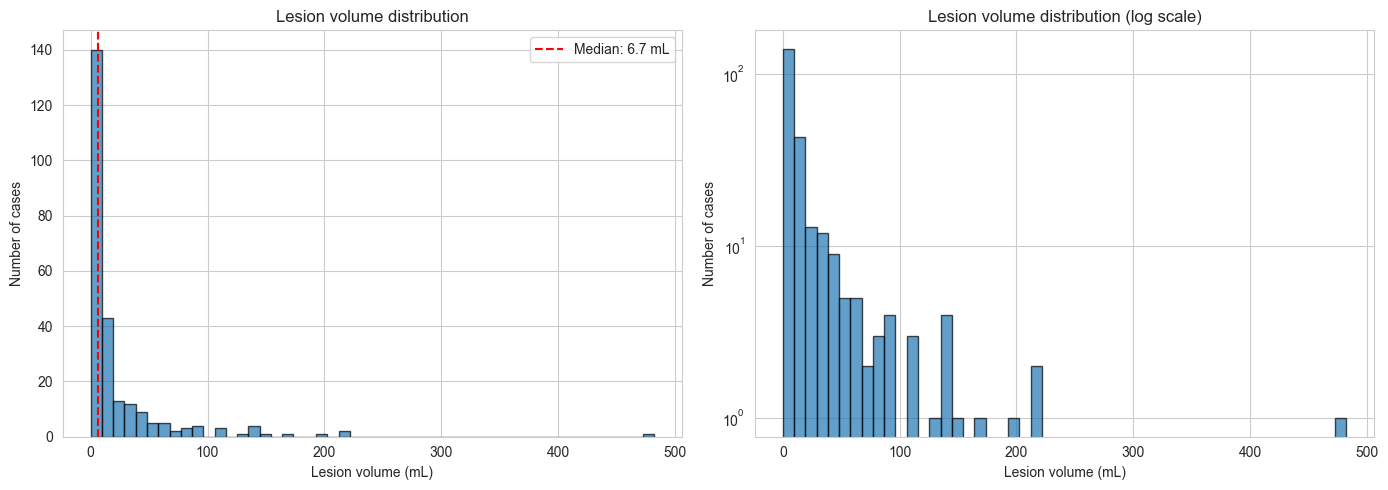

Median: 6.66 mL
Mean:   23.42 mL
Min: 0.00 ml, Max: 482.15 ml


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograms
axes[0].hist(df["volume_ml"], bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Lesion volume (mL)")
axes[0].set_ylabel("Number of cases")
axes[0].set_title("Lesion volume distribution")
axes[0].axvline(df["volume_ml"].median(), color="red", linestyle="--", label=f"Median: {df['volume_ml'].median():.1f} mL")
axes[0].legend()

# Log scale
axes[1].hist(df["volume_ml"], bins=50, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Lesion volume (mL)")
axes[1].set_ylabel("Number of cases")
axes[1].set_title("Lesion volume distribution (log scale)")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

print(f"Median: {df['volume_ml'].median():.2f} mL")
print(f"Mean:   {df['volume_ml'].mean():.2f} mL")
print(f"Min: {df['volume_ml'].min():.2f} ml, Max: {df['volume_ml'].max():.2f} ml")

## 5. Stratification by lesion size

Cases per size category:
size_category
tiny (<1ml)         43
small (1-10ml)      95
medium (10-50ml)    79
large (>50ml)       30
Name: count, dtype: int64


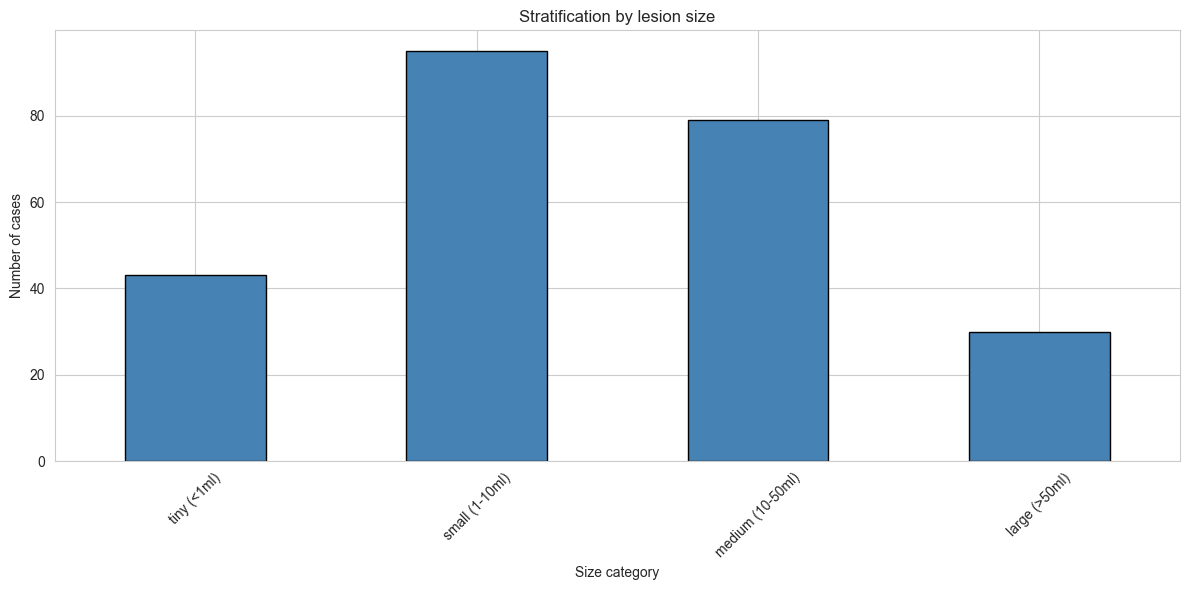

In [8]:
# Size categories
df["size_category"] = pd.cut(
    df["volume_ml"],
    bins=[0, 1, 10, 50, 1000],
    labels=["tiny (<1ml)", "small (1-10ml)", "medium (10-50ml)", "large (>50ml)"]
)

print("Cases per size category:")
print(df["size_category"].value_counts().sort_index())

# Plot
df["size_category"].value_counts().sort_index().plot(kind="bar", color="steelblue", edgecolor="black")
plt.xlabel("Size category")
plt.ylabel("Number of cases")
plt.title("Stratification by lesion size")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Voxel spacing and volume dimensions

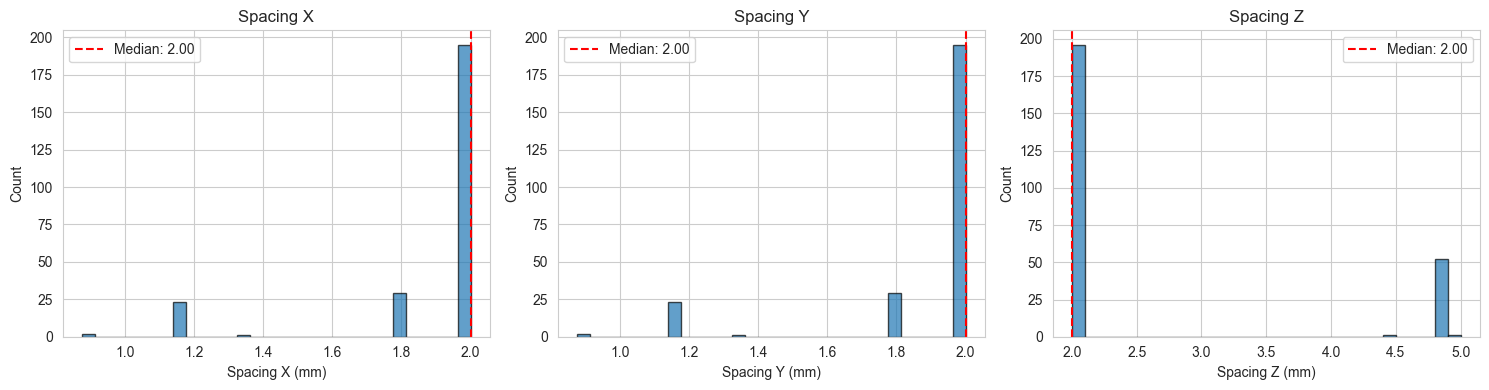

Spacing statistics:
        spacing_x   spacing_y   spacing_z
count  250.000000  250.000000  250.000000
mean     1.886135    1.886135    2.604000
std      0.266519    0.266519    1.153371
min      0.875000    0.875000    2.000000
25%      2.000000    2.000000    2.000000
50%      2.000000    2.000000    2.000000
75%      2.000000    2.000000    2.000000
max      2.000000    2.000000    5.000000


In [9]:
# Spacing distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, axis in enumerate(["x", "y", "z"]):
    col = f"spacing_{axis}"
    axes[i].hist(df[col], bins=30, edgecolor="black", alpha=0.7)
    axes[i].set_xlabel(f"Spacing {axis.upper()} (mm)")
    axes[i].set_ylabel("Count")
    axes[i].set_title(f"Spacing {axis.upper()}")
    axes[i].axvline(df[col].median(), color="red", linestyle="--", label=f"Median: {df[col].median():.2f}")
    axes[i].legend()

plt.tight_layout()
plt.show()

print("Spacing statistics:")
print(df[["spacing_x", "spacing_y", "spacing_z"]].describe())

In [10]:
# Volume dimensions
print("Volume dimensions (shape):")
print(df[["shape_x", "shape_y", "shape_z"]].describe())

Volume dimensions (shape):
         shape_x    shape_y     shape_z
count  250.00000  250.00000  250.000000
mean   122.87600  122.87600   62.736000
std     26.19445   26.19445   18.613871
min    112.00000  112.00000   25.000000
25%    112.00000  112.00000   72.000000
50%    112.00000  112.00000   72.000000
75%    112.00000  112.00000   73.000000
max    256.00000  256.00000   76.000000


## 7. Difficult cases

### 7.1 Tiny lesions (< 1 mL)

In [11]:
tiny_lesions = df[df["volume_ml"] < 1.0]
print(f"Cases with lesions < 1 mL: {len(tiny_lesions)} ({len(tiny_lesions)/len(df)*100:.1f}%)")
print("\nExamples:")
print(tiny_lesions[["subject_id", "volume_ml"]].head(10))

Cases with lesions < 1 mL: 46 (18.4%)

Examples:
            subject_id  volume_ml
1   sub-strokecase0002      0.944
5   sub-strokecase0006      0.040
7   sub-strokecase0008      0.752
11  sub-strokecase0012      0.448
15  sub-strokecase0016      0.208
29  sub-strokecase0030      0.512
31  sub-strokecase0032      0.536
34  sub-strokecase0035      0.144
36  sub-strokecase0037      0.488
44  sub-strokecase0045      0.768


### 7.2 Posterior fossa lesions

In [12]:
# Detecting posterior fossa lesions requires the lesion centre of mass in a
# common anatomical frame. Deferred: the segmentation model does not depend on
# it, and the centroid heuristics live in src/findings/location.py instead.
print("Posterior fossa detection: see src/findings/location.py (centroid heuristics)")

Posterior fossa detection: see src/findings/location.py (centroid heuristics)


## 8. Example visualisations


sub-strokecase0001 -- volume: 6.68 mL


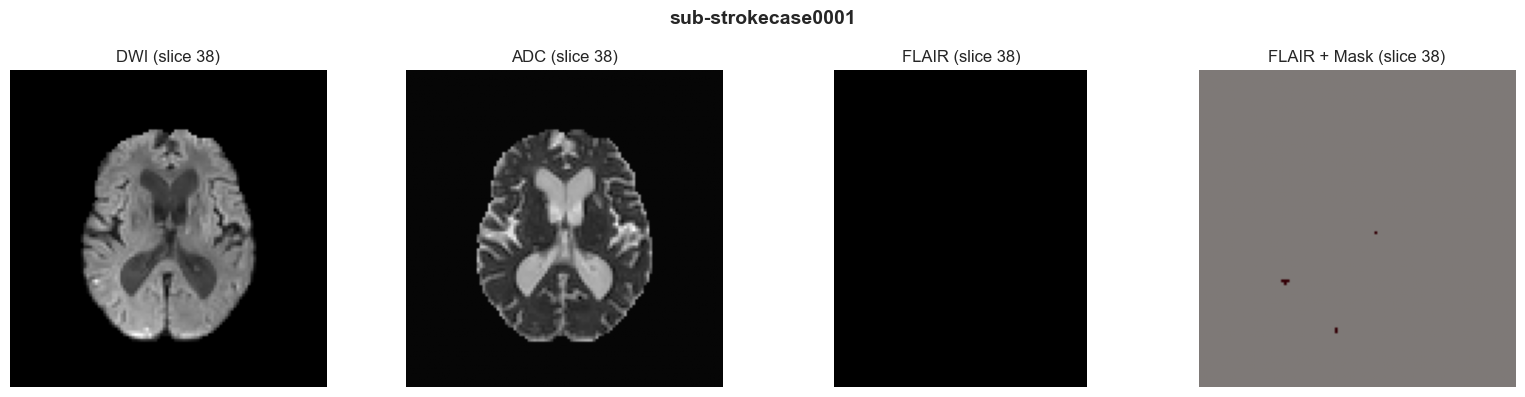


sub-strokecase0023 -- volume: 482.15 mL


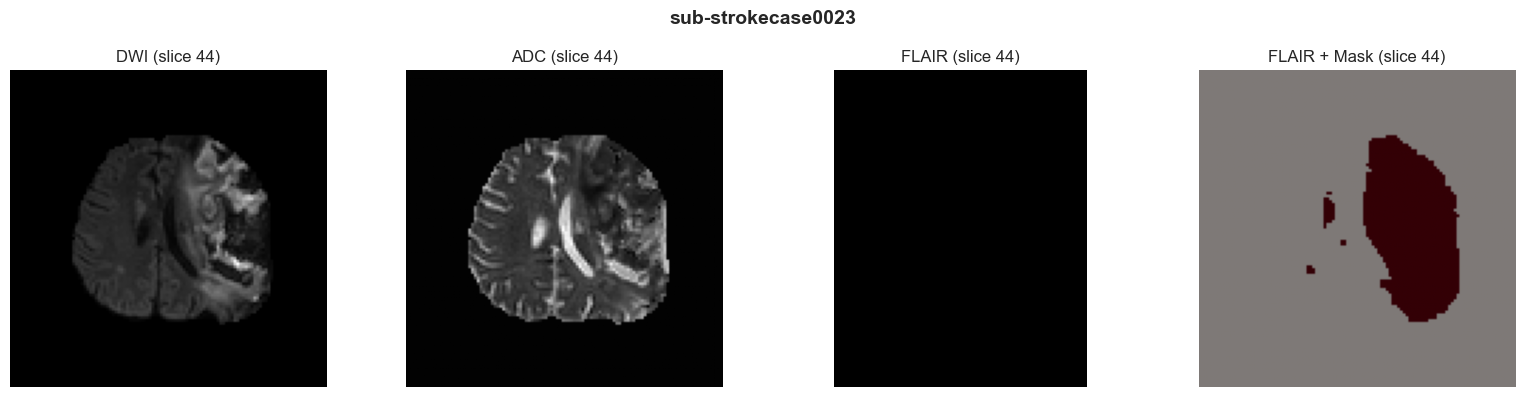


sub-strokecase0150 -- volume: 0.00 mL


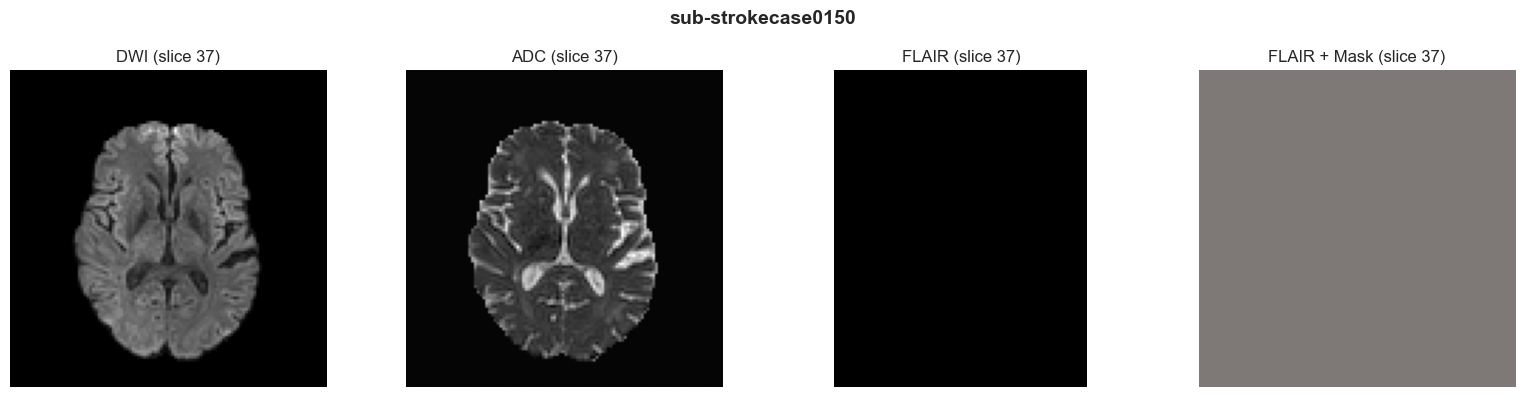

In [13]:
def visualize_case(subject_id: str, slice_idx: int = None):
    """Plot one case: DWI, ADC, FLAIR and the lesion mask."""
    paths = load_subject_paths(subject_id)
    
    dwi_img = nib.load(paths["dwi"]).get_fdata()
    adc_img = nib.load(paths["adc"]).get_fdata()
    flair_img = nib.load(paths["flair"]).get_fdata()
    mask_img = nib.load(paths["mask"]).get_fdata()
    
    # Pick the slice with the most lesion voxels
    if slice_idx is None:
        lesion_slices = np.where(mask_img.sum(axis=(0, 1)) > 0)[0]
        if len(lesion_slices) > 0:
            slice_idx = lesion_slices[len(lesion_slices) // 2]  # middle slice containing lesion
        else:
            slice_idx = mask_img.shape[2] // 2
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    axes[0].imshow(dwi_img[:, :, slice_idx].T, cmap="gray", origin="lower")
    axes[0].set_title(f"DWI (slice {slice_idx})")
    axes[0].axis("off")
    
    axes[1].imshow(adc_img[:, :, slice_idx].T, cmap="gray", origin="lower")
    axes[1].set_title(f"ADC (slice {slice_idx})")
    axes[1].axis("off")
    
    axes[2].imshow(flair_img[:, :, slice_idx].T, cmap="gray", origin="lower")
    axes[2].set_title(f"FLAIR (slice {slice_idx})")
    axes[2].axis("off")
    
    axes[3].imshow(flair_img[:, :, slice_idx].T, cmap="gray", origin="lower")
    axes[3].imshow(mask_img[:, :, slice_idx].T, cmap="Reds", alpha=0.5, origin="lower")
    axes[3].set_title(f"FLAIR + Mask (slice {slice_idx})")
    axes[3].axis("off")
    
    plt.suptitle(f"{subject_id}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


# Visualise a few representative cases
example_subjects = [
    subjects[0],  # first case
    df.loc[df["volume_ml"].idxmax(), "subject_id"],  # largest lesion
    df.loc[df["volume_ml"].idxmin(), "subject_id"],  # smallest lesion
]

for subj in example_subjects:
    volume = df.loc[df["subject_id"] == subj, "volume_ml"].values[0]
    print(f"\n{subj} -- volume: {volume:.2f} mL")
    visualize_case(subj)

## 9. Save metadata

In [14]:
# Persist for downstream use
output_path = project_root / "data" / "processed" / "isles22_metadata.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_path, index=False)
print(f"Metadata saved to: {output_path.relative_to(project_root).as_posix()}")

Metadata saved to: data/processed/isles22_metadata.csv


## 10. Findings

**Dataset size:** 250 cases, all with DWI, ADC, FLAIR and an expert lesion mask.

**Lesion volume:** median 6.66 mL, ranging from 0 to 482 mL. The distribution is
heavily right-skewed, which is why the log-scale histogram above is the readable one.

**Size strata:** 43 tiny (<1 mL), 95 small (1-10 mL), 79 medium (10-50 mL),
30 large (>50 mL). Tiny lesions are a sixth of the dataset and turn out to be by far
the hardest category for the model.

**Spacing:** mostly 2x2x2 mm, but in-plane resolution varies from 0.88 to 2.0 mm and
slice thickness from 2.0 to 5.0 mm. Volumes range 112-256 x 112-256 x 25-76 voxels,
so resampling to a common grid is mandatory.

**Data issues:** 3 cases carry an empty mask (0 voxels) -- sub-strokecase0150, 0151
and 0170. They are kept in the splits and tracked separately during evaluation.
FLAIR is frequently acquired at a different resolution than DWI/ADC.

---

**Next steps:**
- Build stratified 5-fold cross-validation splits
- Implement the Dataset class
- Preprocessing pipeline